### Stock price prediction project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:

df=pd.read_csv("UPCL.csv")

In [3]:
df

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1
...,...,...,...,...,...,...,...,...,...
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1


In [4]:
df.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1


In [5]:
df.tail()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1
1522,2026-02-17,384.9,384.9,371.4,373.0,-1.17,180630.0,67463595.4,-1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   published_date   1523 non-null   object 
 1   open             1523 non-null   float64
 2   high             1523 non-null   float64
 3   low              1523 non-null   float64
 4   close            1523 non-null   float64
 5   per_change       1523 non-null   float64
 6   traded_quantity  1523 non-null   float64
 7   traded_amount    1523 non-null   float64
 8   status           1523 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 107.2+ KB


In [7]:
#Convert the date in date format
df['published_date'] = pd.to_datetime(df['published_date'])

#sort by date
df = df.sort_values('published_date')

In [42]:
df

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,price_range,daily_return,ma_5,ma_10,vol_ma_5,close_lag1
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1,6.0,NaN,NaN,NaN,NaN,NaN
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1,6.0,0.052632,NaN,NaN,NaN,95.0
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1,8.0,-0.040000,NaN,NaN,NaN,100.0
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0,2.0,0.000000,NaN,NaN,NaN,96.0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1,2.0,-0.020833,96.20,NaN,19296.4,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1,16.4,0.008065,377.00,379.50,179007.4,372.0
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1,9.4,0.012000,377.70,377.95,190405.4,375.0
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1,20.7,0.006851,377.12,377.06,213553.8,379.5
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1,12.8,-0.012300,377.20,376.90,208396.2,382.1


In [43]:
# ===== Feature Engineering =====

# Price range (volatility signal)
df['price_range'] = df['high'] - df['low']

# Daily return
df['daily_return'] = df['close'].pct_change()

# Moving averages (VERY POWERFUL)
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_10'] = df['close'].rolling(window=10).mean()

# Volume moving average
df['vol_ma_5'] = df['traded_quantity'].rolling(window=5).mean()

# Lag feature (EXTREMELY IMPORTANT)
df['close_lag1'] = df['close'].shift(1)

In [74]:
#select the features
features = [
    'open',
    'high',
    'low',
    'close',
    'traded_quantity',
    'traded_amount'
]


In [75]:
#Create target for next day closing
#This is the most important and core of prediction
df_model = df[features].copy()

# Create target
df_model['Target'] = df['close'].shift(-1)

# Drop NaNs (IMPORTANT — many will appear)
df_model.dropna(inplace=True)

In [76]:
df_model.head()

,open,high,low,close,traded_quantity,traded_amount,Target
0,91.0,97.0,91.0,95.0,14515.0,1368205.0,100.0
1,96.0,102.0,96.0,100.0,51310.0,5040190.0,96.0
2,98.0,102.0,94.0,96.0,20010.0,1941570.0,96.0
3,96.0,96.0,94.0,96.0,6955.0,659760.0,94.0
4,96.0,96.0,94.0,94.0,3692.0,350186.0,97.0


In [77]:
df.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,price_range,daily_return,ma_5,ma_10,vol_ma_5,close_lag1
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1,6.0,NaN,NaN,NaN,NaN,NaN
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1,6.0,0.052632,NaN,NaN,NaN,95.0
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1,8.0,-0.040000,NaN,NaN,NaN,100.0
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0,2.0,0.000000,NaN,NaN,NaN,96.0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1,2.0,-0.020833,96.2,NaN,19296.4,96.0


In [78]:
df_model.tail()

,open,high,low,close,traded_quantity,traded_amount,Target
1517,381.0,381.0,371.0,372.0,150551.0,56243410.4,375.0
1518,364.6,381.0,364.6,375.0,207322.0,78142545.9,379.5
1519,375.0,384.4,375.0,379.5,183138.0,69589109.8,382.1
1520,372.0,392.7,372.0,382.1,365311.0,141396818.9,377.4
1521,375.0,387.8,375.0,377.4,135659.0,51723961.8,373.0


In [79]:
df.tail()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,price_range,daily_return,ma_5,ma_10,vol_ma_5,close_lag1
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1,16.4,0.008065,377.00,379.50,179007.4,372.0
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1,9.4,0.012000,377.70,377.95,190405.4,375.0
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1,20.7,0.006851,377.12,377.06,213553.8,379.5
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1,12.8,-0.012300,377.20,376.90,208396.2,382.1
1522,2026-02-17,384.9,384.9,371.4,373.0,-1.17,180630.0,67463595.4,-1,13.5,-0.011659,377.40,377.00,214412.0,377.4


In [80]:
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1513, 1514, 1515, 1516, 1517, 1518, 1519, 1520, 1521, 1522],
      dtype='int64', length=1523)

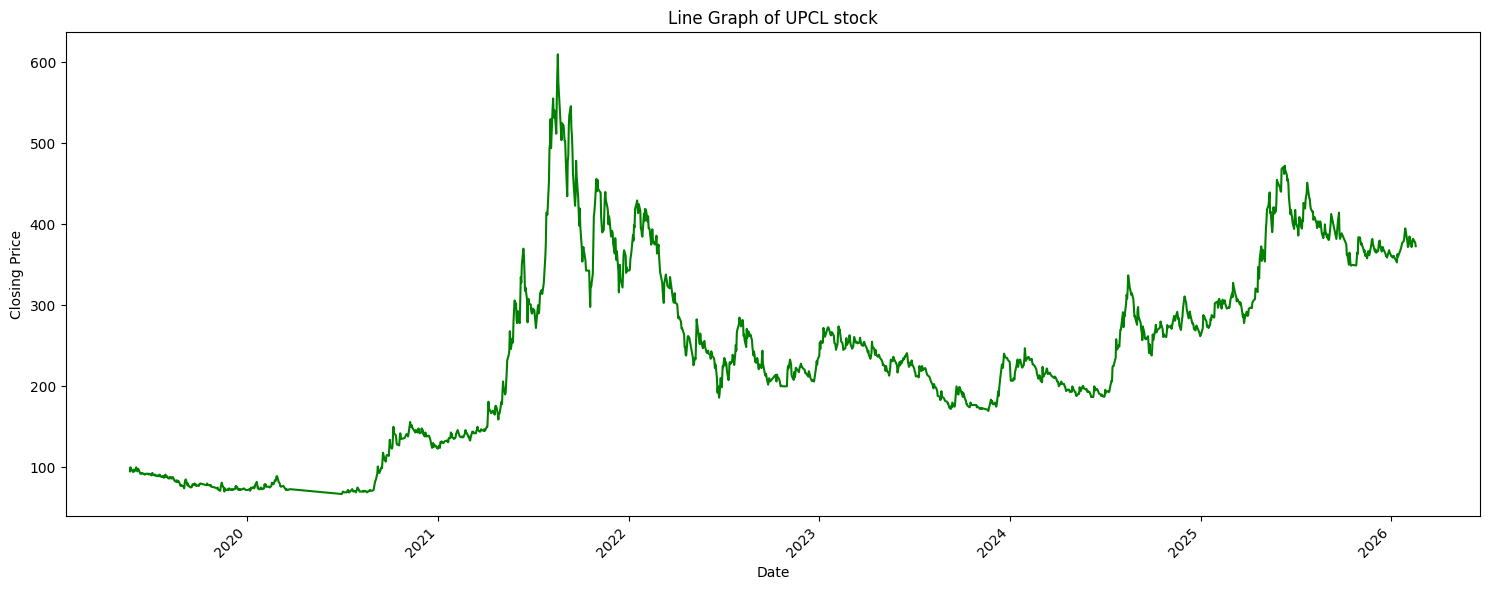

In [81]:
plt.figure(figsize=(15,6))
plt.plot(df['published_date'],df['close'],color="Green")
plt.xlabel("Date")
plt.title("Line Graph of UPCL stock")
plt.ylabel("Closing Price")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

In [82]:
#manual split of data for taining and testing
X = df_model[features]
y = df_model['Target']

X_train = X.iloc[:-100]
X_test  = X.iloc[-100:]

y_train = y.iloc[:-100]
y_test  = y.iloc[-100:]

In [83]:
#train using random forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,      # allow full depth
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [84]:
#Predict and evaluate
preds = model.predict(X_test)

from sklearn.metrics import r2_score
print("R2 score:", r2_score(y_test, preds))

R2 score: 0.26697358940520477


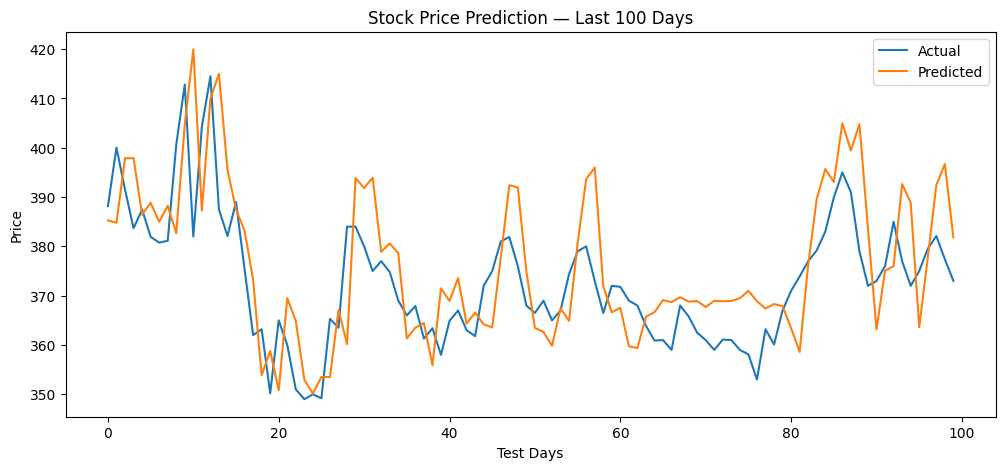

In [85]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("Stock Price Prediction — Last 100 Days")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.show()